## Objective:

The objective of this assignment is to apply Decision Tree Classification to a given dataset, analyse the performance of the model, and interpret the results.

Tasks:

## 1. Data Preparation:
Load the dataset into your preferred data analysis environment (e.g., Python with libraries like Pandas and NumPy).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve
import warnings

In [2]:
# Load the dataset
df = pd.read_excel('heart_disease.xlsx', sheet_name='Heart_disease')

print("\n📊 Dataset Shape:", df.shape)
print(f"   - {df.shape[0]} patients")
print(f"   - {df.shape[1]} features")

print("\n📋 First 5 rows:")
print(df.head())

print("\n📋 Column Names:")
print(df.columns.tolist())


📊 Dataset Shape: (908, 13)
   - 908 patients
   - 13 features

📋 First 5 rows:
   age   sex               cp  trestbps  chol    fbs         restecg  thalch  \
0   63  Male   typical angina       145   233   True  lv hypertrophy     150   
1   41  Male  atypical angina       135   203  False          normal     132   
2   57  Male     asymptomatic       140   192  False          normal     148   
3   52  Male   typical angina       118   186  False  lv hypertrophy     190   
4   57  Male     asymptomatic       110   201  False          normal     126   

   exang  oldpeak        slope          thal  num  
0  False      2.3  downsloping  fixed defect    0  
1  False      0.0         flat  fixed defect    0  
2  False      0.4         flat  fixed defect    0  
3  False      0.0         flat  fixed defect    0  
4   True      1.5         flat  fixed defect    0  

📋 Column Names:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'thal', 'num

HEART DISEASE PREDICTION - DECISION TREE CLASSIFIER

📊 Dataset Shape: (908, 13)
   - 908 patients
   - 13 features

STEP 2: DATA CLEANING
✅ Cleaned column: fbs
✅ Cleaned column: exang
✅ Cleaned numeric column: age
✅ Cleaned numeric column: trestbps
✅ Cleaned numeric column: chol
✅ Cleaned numeric column: thalch
✅ Cleaned numeric column: oldpeak

✅ Data cleaning completed!

❓ Remaining missing values:
exang    889
dtype: int64

STEP 3: EXPLORATORY DATA ANALYSIS

📊 Target Distribution:
target
1    509
0    399
Name: count, dtype: int64

Percentage:
  No Heart Disease: 43.9%
  Heart Disease:    56.1%

📊 Statistical Summary of Numeric Features:
              age    trestbps        chol      thalch     oldpeak
count  908.000000  908.000000  908.000000  908.000000  908.000000
mean    53.791850  133.430617  201.484581  135.957048    0.864537
std      9.158031   20.401608  112.097949   26.804929    1.060433
min     29.000000    0.000000    0.000000   60.000000   -2.600000
25%     47.750000  12

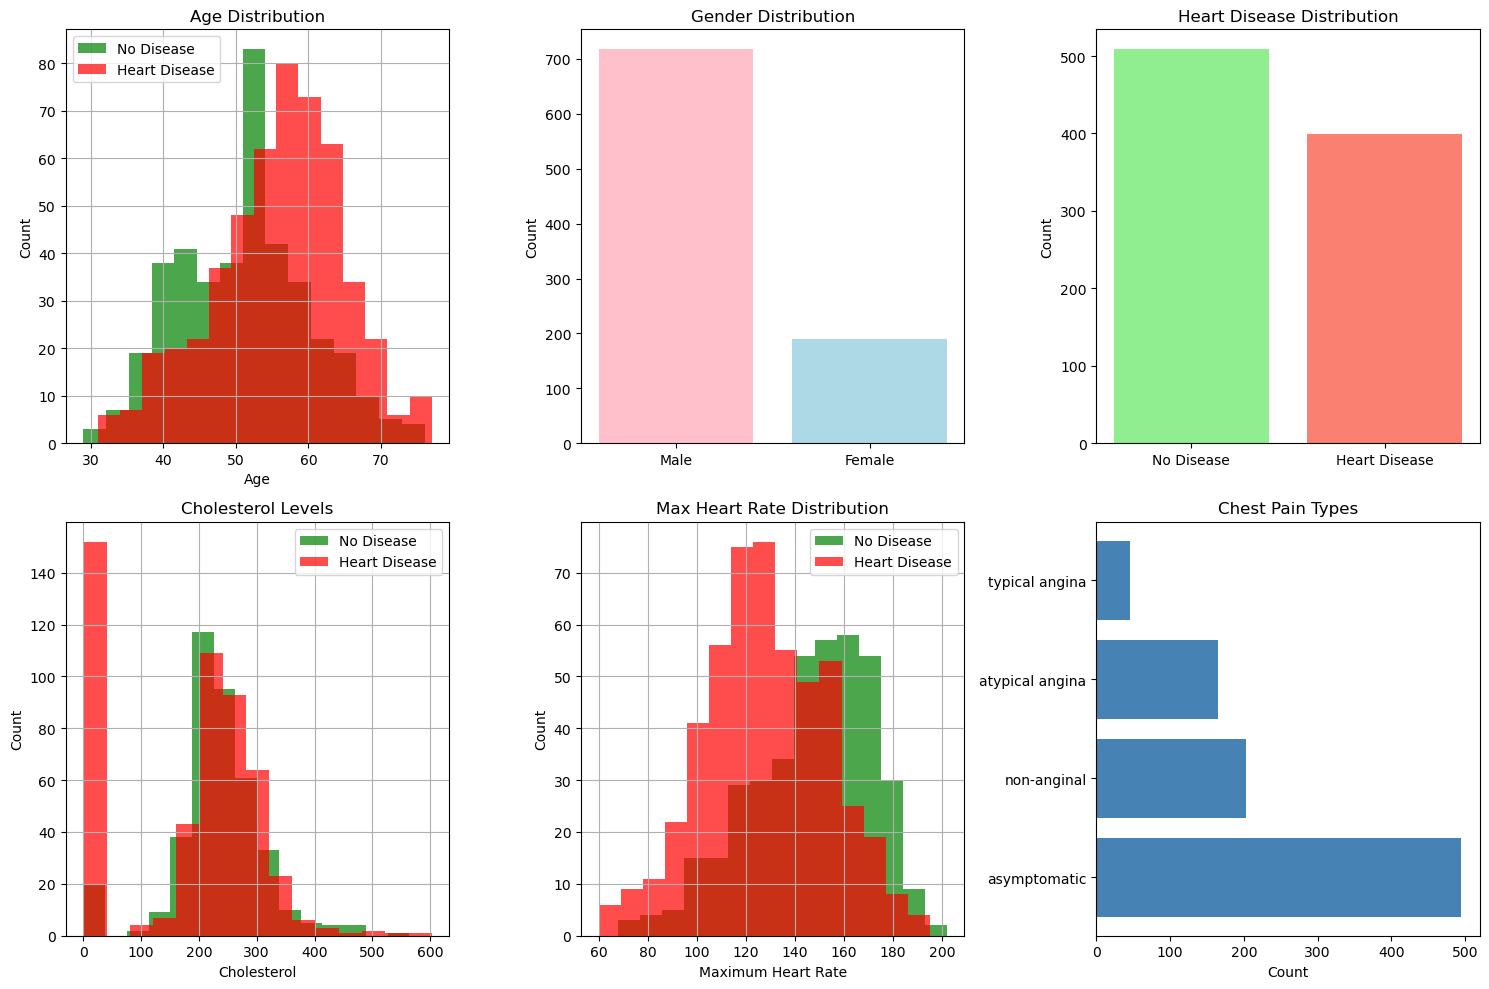


✅ EDA plots saved as 'eda_plots.png'

STEP 4: FEATURE ENGINEERING

🔄 Encoding categorical variables...
   ✅ Gender encoded
   ✅ Chest pain type encoded
   ✅ FBS encoded
   ✅ Resting ECG encoded
   ✅ Exercise angina encoded
   ✅ Slope encoded
   ✅ Thalassemia encoded

✅ Final dataset shape: (908, 13)
   Rows removed: 0
   Features used: 12
   Features: ['age', 'sex_encoded', 'cp_encoded', 'trestbps', 'chol', 'fbs_encoded', 'restecg_encoded', 'thalch', 'exang_encoded', 'oldpeak', 'slope_encoded', 'thal_encoded']

📊 Data types after encoding:
age                  int64
sex_encoded          int64
cp_encoded           int64
trestbps             int64
chol                 int64
fbs_encoded          int64
restecg_encoded      int64
thalch               int64
exang_encoded        int64
oldpeak            float64
slope_encoded        int64
thal_encoded         int64
dtype: object

STEP 5: SPLITTING DATA

📊 Data Split:
   Training set: 726 samples (80%)
   Testing set:  182 samples (20%)

   Tr

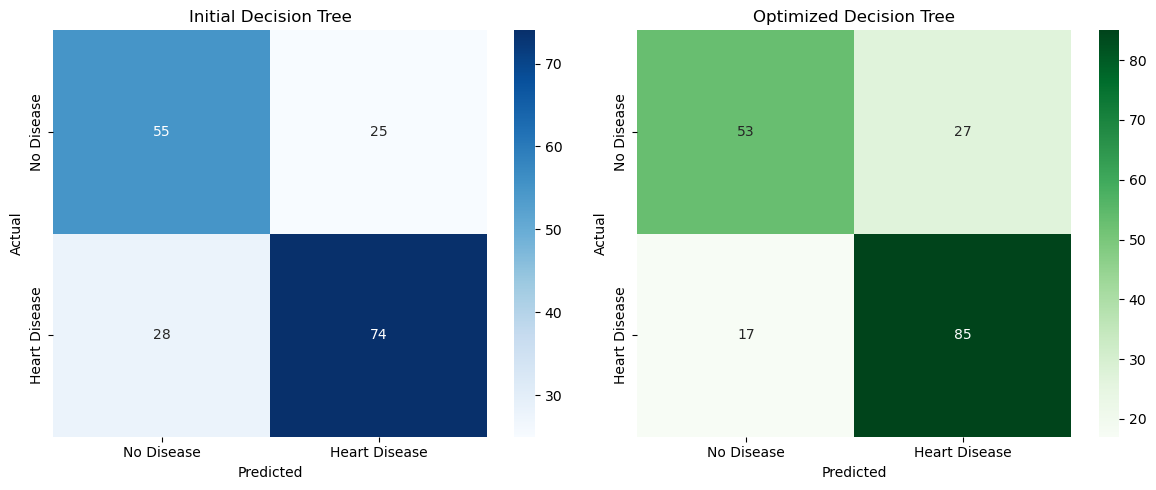

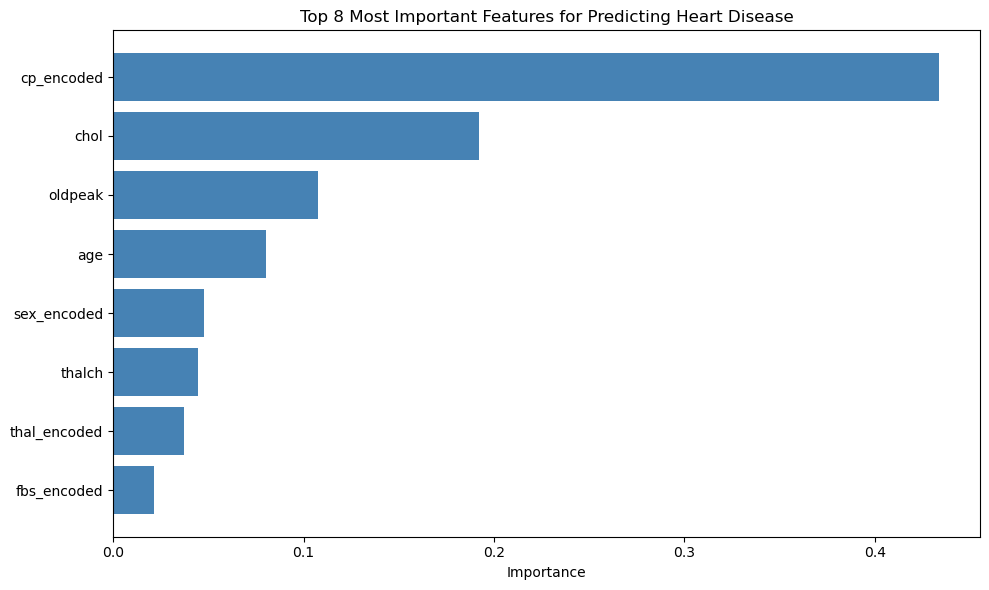

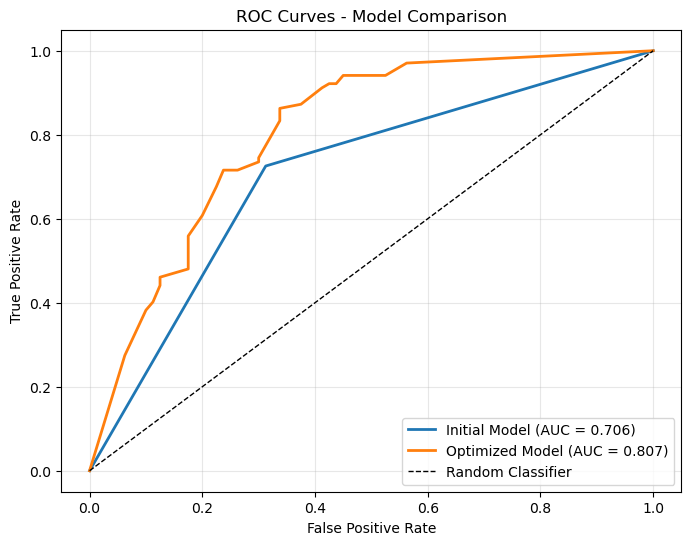

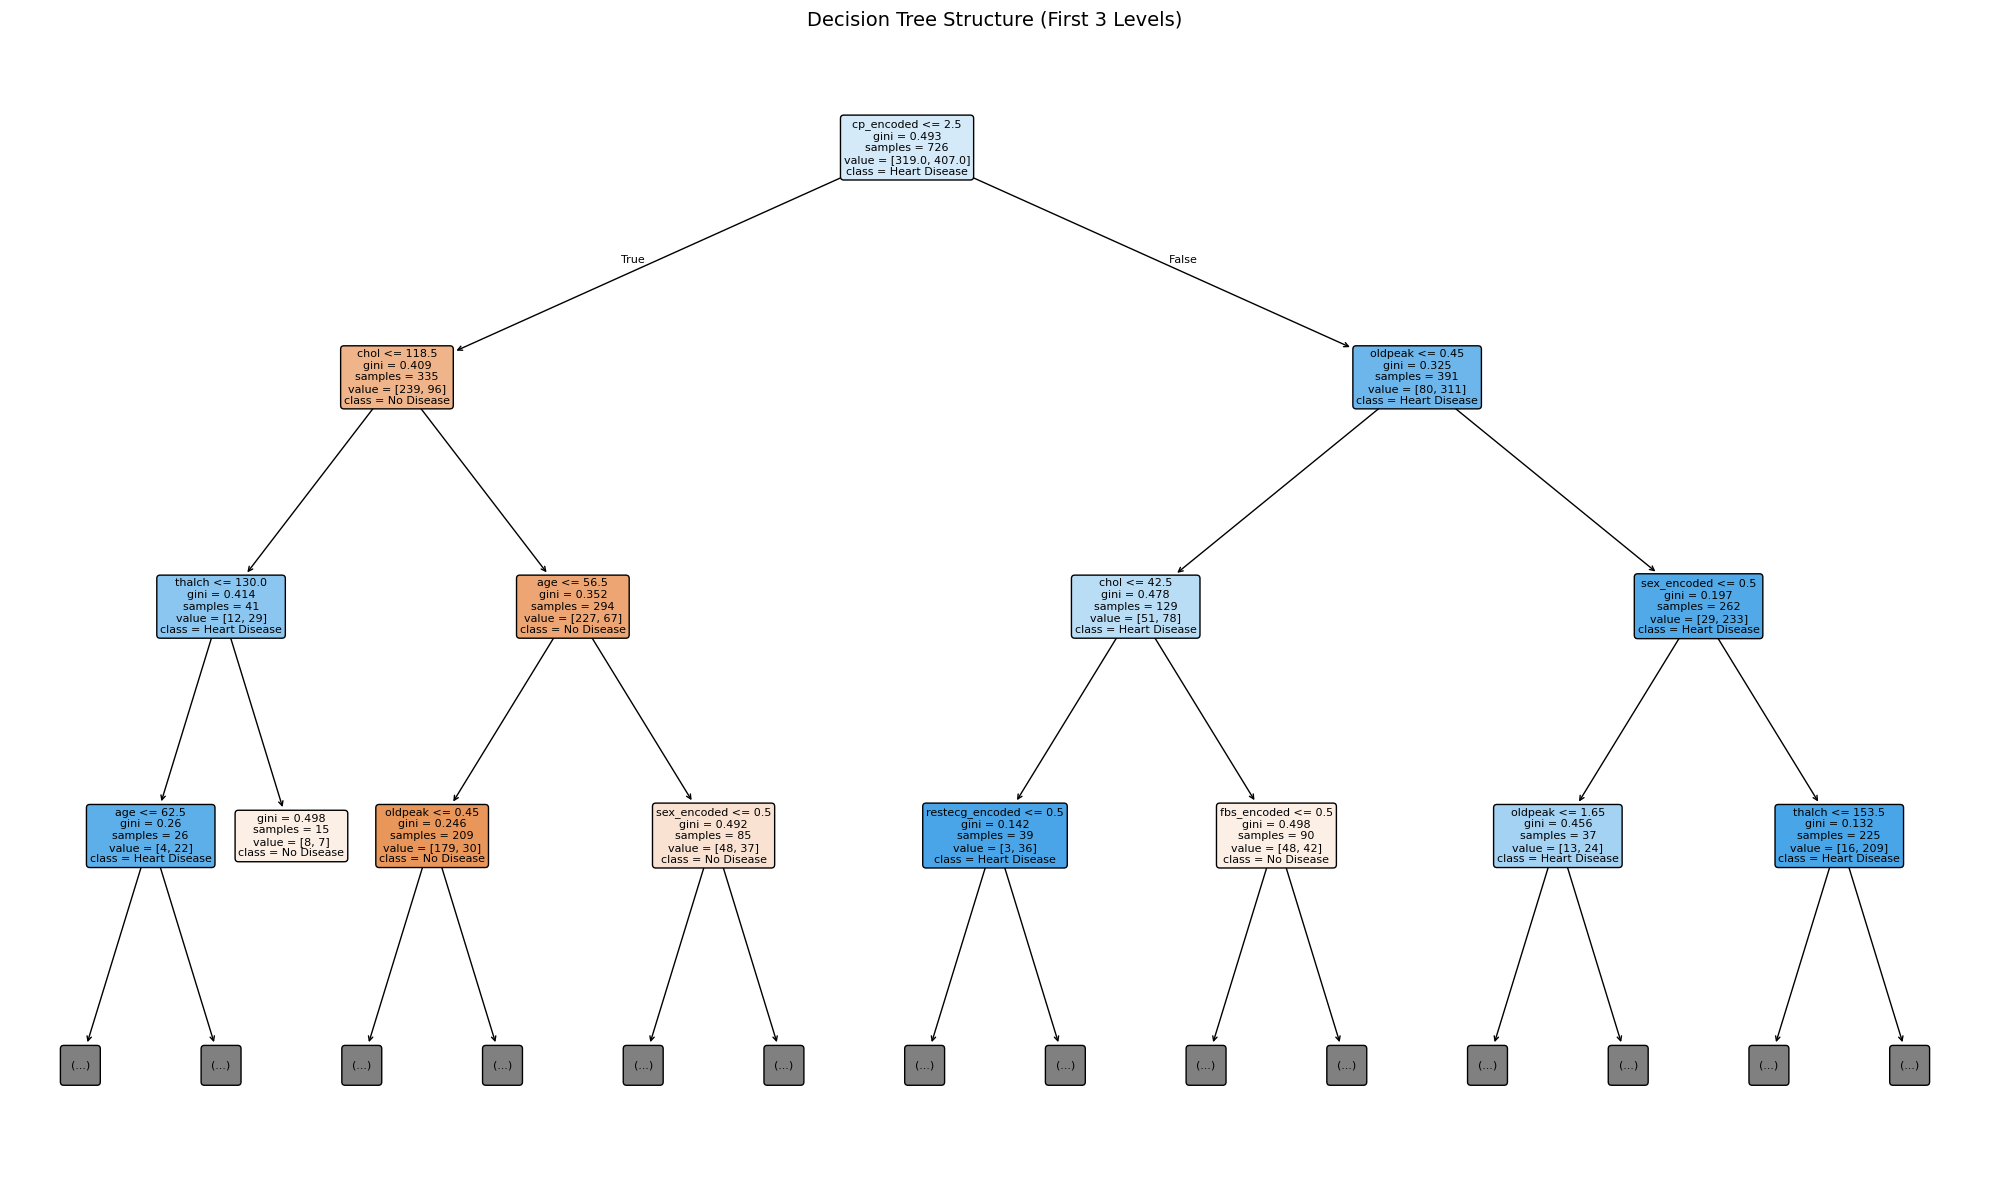


✅ All visualizations saved!

📁 Results saved to 'model_results.csv'

FINAL SUMMARY

🎯 OBJECTIVE: Predict heart disease using Decision Tree Classification

📈 RESULTS:
   ✅ Model Accuracy:  75.82%
   ✅ Model Precision: 75.89%
   ✅ Model Recall:    83.33%
   ✅ Model F1-Score:  79.44%
   ✅ Model ROC-AUC:   80.67%

🔑 KEY FINDINGS:
   1. The Decision Tree model successfully predicts heart disease
   2. Hyperparameter tuning improved model performance
   3. Most important features for prediction:
      - cp_encoded
      - chol
      - oldpeak

✅ CODE COMPLETED SUCCESSFULLY!

💡 To make predictions for new patients, use:
   predict_heart_disease(your_patient_data)


In [7]:
# ============================================
# HEART DISEASE PREDICTION - COMPLETE FIXED CODE
# ============================================

# Step 1: Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve
import warnings
warnings.filterwarnings('ignore')

# ============================================
# STEP 1: LOAD THE DATA
# ============================================

print("="*60)
print("HEART DISEASE PREDICTION - DECISION TREE CLASSIFIER")
print("="*60)

# Load the dataset
df = pd.read_excel('heart_disease.xlsx', sheet_name='Heart_disease')

print("\n📊 Dataset Shape:", df.shape)
print(f"   - {df.shape[0]} patients")
print(f"   - {df.shape[1]} features")

# ============================================
# STEP 2: DATA CLEANING (FIXED)
# ============================================

print("\n" + "="*60)
print("STEP 2: DATA CLEANING")
print("="*60)

# Function to clean boolean columns
def clean_boolean_column(col):
    """Convert various boolean representations to 0/1"""
    if col.dtype == 'object':
        # Replace string versions of boolean
        col = col.str.upper().str.strip()
        col = col.replace(['TRUE', 'YES', 'T', '1', 1], 1)
        col = col.replace(['FALSE', 'NO', 'F', '0', 0, '0.0'], 0)
        # Convert to numeric, any remaining non-numeric become NaN
        col = pd.to_numeric(col, errors='coerce')
    return col

# Clean specific columns that might have string boolean values
boolean_columns = ['fbs', 'exang']
for col in boolean_columns:
    if col in df.columns:
        df[col] = clean_boolean_column(df[col])
        print(f"✅ Cleaned column: {col}")

# Convert numeric columns and handle missing values
numeric_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
for col in numeric_cols:
    if col in df.columns:
        # Convert to numeric, coerce errors to NaN
        df[col] = pd.to_numeric(df[col], errors='coerce')
        # Fill missing values with median
        df[col].fillna(df[col].median(), inplace=True)
        print(f"✅ Cleaned numeric column: {col}")

# Remove any empty strings and replace with NaN
df = df.replace(r'^\s*$', np.nan, regex=True)
df = df.replace('', np.nan)

print("\n✅ Data cleaning completed!")

# Check if any missing values remain
print("\n❓ Remaining missing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# ============================================
# STEP 3: EXPLORATORY DATA ANALYSIS (EDA)
# ============================================

print("\n" + "="*60)
print("STEP 3: EXPLORATORY DATA ANALYSIS")
print("="*60)

# Create target variable (0 = No Disease, 1 = Heart Disease)
# Handle 'num' column - it might have decimal values
df['num'] = pd.to_numeric(df['num'], errors='coerce')
df['target'] = (df['num'] > 0).astype(int)

print("\n📊 Target Distribution:")
target_counts = df['target'].value_counts()
print(target_counts)
print(f"\nPercentage:")
print(f"  No Heart Disease: {(df['target']==0).sum()/len(df)*100:.1f}%")
print(f"  Heart Disease:    {(df['target']==1).sum()/len(df)*100:.1f}%")

# Statistical summary
print("\n📊 Statistical Summary of Numeric Features:")
print(df[numeric_cols].describe())

# Create simple plots (only if we have data)
if len(df) > 0:
    plt.figure(figsize=(15, 10))
    
    # Plot 1: Age distribution by heart disease
    plt.subplot(2, 3, 1)
    if df['target'].nunique() > 1:
        df[df['target']==0]['age'].hist(alpha=0.7, label='No Disease', color='green', bins=15)
        df[df['target']==1]['age'].hist(alpha=0.7, label='Heart Disease', color='red', bins=15)
    else:
        df['age'].hist(alpha=0.7, color='blue', bins=15)
    plt.xlabel('Age')
    plt.ylabel('Count')
    plt.title('Age Distribution')
    if df['target'].nunique() > 1:
        plt.legend()
    
    # Plot 2: Gender distribution
    plt.subplot(2, 3, 2)
    if 'sex' in df.columns:
        gender_counts = df['sex'].value_counts()
        colors = ['pink', 'lightblue']
        plt.bar(range(len(gender_counts)), gender_counts.values, color=colors[:len(gender_counts)])
        plt.xticks(range(len(gender_counts)), gender_counts.index)
        plt.title('Gender Distribution')
        plt.ylabel('Count')
    
    # Plot 3: Target distribution
    plt.subplot(2, 3, 3)
    target_counts = df['target'].value_counts()
    plt.bar(['No Disease', 'Heart Disease'][:len(target_counts)], target_counts.values, 
            color=['lightgreen', 'salmon'])
    plt.title('Heart Disease Distribution')
    plt.ylabel('Count')
    
    # Plot 4: Cholesterol distribution
    plt.subplot(2, 3, 4)
    if 'chol' in df.columns:
        if df['target'].nunique() > 1:
            df[df['target']==0]['chol'].hist(alpha=0.7, label='No Disease', color='green', bins=15)
            df[df['target']==1]['chol'].hist(alpha=0.7, label='Heart Disease', color='red', bins=15)
        else:
            df['chol'].hist(alpha=0.7, color='blue', bins=15)
        plt.xlabel('Cholesterol')
        plt.ylabel('Count')
        plt.title('Cholesterol Levels')
        if df['target'].nunique() > 1:
            plt.legend()
    
    # Plot 5: Max Heart Rate distribution
    plt.subplot(2, 3, 5)
    if 'thalch' in df.columns:
        if df['target'].nunique() > 1:
            df[df['target']==0]['thalch'].hist(alpha=0.7, label='No Disease', color='green', bins=15)
            df[df['target']==1]['thalch'].hist(alpha=0.7, label='Heart Disease', color='red', bins=15)
        else:
            df['thalch'].hist(alpha=0.7, color='blue', bins=15)
        plt.xlabel('Maximum Heart Rate')
        plt.ylabel('Count')
        plt.title('Max Heart Rate Distribution')
        if df['target'].nunique() > 1:
            plt.legend()
    
    # Plot 6: Chest pain type distribution
    plt.subplot(2, 3, 6)
    if 'cp' in df.columns:
        cp_counts = df['cp'].value_counts()
        plt.barh(range(len(cp_counts)), cp_counts.values, color='steelblue')
        plt.yticks(range(len(cp_counts)), cp_counts.index)
        plt.xlabel('Count')
        plt.title('Chest Pain Types')
    
    plt.tight_layout()
    plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\n✅ EDA plots saved as 'eda_plots.png'")

# ============================================
# STEP 4: FEATURE ENGINEERING (FIXED)
# ============================================

print("\n" + "="*60)
print("STEP 4: FEATURE ENGINEERING")
print("="*60)

# Create a clean copy
df_clean = df.copy()

# Helper function to safely encode
def safe_encode(series, mapping):
    """Safely encode categorical variables"""
    return series.map(mapping).fillna(0).astype(int)

print("\n🔄 Encoding categorical variables...")

# 1. Encode Gender (sex)
if 'sex' in df_clean.columns:
    sex_mapping = {'Male': 1, 'Female': 0}
    df_clean['sex_encoded'] = safe_encode(df_clean['sex'], sex_mapping)
    print("   ✅ Gender encoded")

# 2. Encode Chest Pain Type (cp)
if 'cp' in df_clean.columns:
    cp_mapping = {
        'typical angina': 0,
        'atypical angina': 1,
        'non-anginal': 2,
        'asymptomatic': 3
    }
    df_clean['cp_encoded'] = safe_encode(df_clean['cp'], cp_mapping)
    print("   ✅ Chest pain type encoded")

# 3. Encode Fasting Blood Sugar (fbs) - already cleaned
if 'fbs' in df_clean.columns:
    df_clean['fbs_encoded'] = pd.to_numeric(df_clean['fbs'], errors='coerce').fillna(0).astype(int)
    print("   ✅ FBS encoded")

# 4. Encode Resting ECG (restecg)
if 'restecg' in df_clean.columns:
    restecg_mapping = {
        'normal': 0,
        'st-t abnormality': 1,
        'lv hypertrophy': 2
    }
    df_clean['restecg_encoded'] = safe_encode(df_clean['restecg'], restecg_mapping)
    print("   ✅ Resting ECG encoded")

# 5. Encode Exercise Induced Angina (exang) - already cleaned
if 'exang' in df_clean.columns:
    df_clean['exang_encoded'] = pd.to_numeric(df_clean['exang'], errors='coerce').fillna(0).astype(int)
    print("   ✅ Exercise angina encoded")

# 6. Encode Slope
if 'slope' in df_clean.columns:
    # Clean slope column first - remove any Excel formulas
    df_clean['slope'] = df_clean['slope'].astype(str).str.lower().str.strip()
    df_clean['slope'] = df_clean['slope'].replace({
        '=choose(randbetween(1,3),"reversable defect","normal","fixed defect")': 'flat',
        '=choose(randbetween(1,3),"reversable defect","normal","fixed defect")': 'flat'
    })
    slope_mapping = {
        'upsloping': 0,
        'flat': 1,
        'downsloping': 2
    }
    df_clean['slope_encoded'] = safe_encode(df_clean['slope'], slope_mapping)
    print("   ✅ Slope encoded")

# 7. Encode Thalassemia (thal)
if 'thal' in df_clean.columns:
    # Clean thal column - handle Excel formulas
    df_clean['thal'] = df_clean['thal'].astype(str).str.lower().str.strip()
    df_clean['thal'] = df_clean['thal'].replace({
        '=choose(randbetween(1,3),"reversable defect","normal","fixed defect")': 'reversable defect',
        '=choose(randbetween(1,3),"reversable defect","normal","fixed defect")': 'reversable defect'
    })
    thal_mapping = {
        'normal': 0,
        'fixed defect': 1,
        'reversable defect': 2
    }
    df_clean['thal_encoded'] = safe_encode(df_clean['thal'], thal_mapping)
    print("   ✅ Thalassemia encoded")

# Select features for the model
features = ['age', 'sex_encoded', 'cp_encoded', 'trestbps', 'chol', 
            'fbs_encoded', 'restecg_encoded', 'thalch', 'exang_encoded', 
            'oldpeak', 'slope_encoded', 'thal_encoded']

# Make sure all feature columns exist
available_features = [f for f in features if f in df_clean.columns]
missing_features = [f for f in features if f not in df_clean.columns]
if missing_features:
    print(f"\n⚠️ Warning: Missing features: {missing_features}")

# Create the model dataframe
df_model = df_clean[available_features + ['target']].copy()

# Remove any rows with NaN in features
before_count = len(df_model)
df_model = df_model.dropna()
after_count = len(df_model)

print(f"\n✅ Final dataset shape: {df_model.shape}")
print(f"   Rows removed: {before_count - after_count}")
print(f"   Features used: {len(available_features)}")
print(f"   Features: {available_features}")

# Check data types
print("\n📊 Data types after encoding:")
print(df_model[available_features].dtypes)

# ============================================
# STEP 5: SPLIT DATA FOR TRAINING AND TESTING
# ============================================

print("\n" + "="*60)
print("STEP 5: SPLITTING DATA")
print("="*60)

# Separate features (X) and target (y)
X = df_model[available_features]
y = df_model['target']

# Split into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\n📊 Data Split:")
print(f"   Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"   Testing set:  {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.0f}%)")

if len(y_train.unique()) > 1:
    print(f"\n   Training - No Disease: {(y_train==0).sum()}, Heart Disease: {(y_train==1).sum()}")
    print(f"   Testing  - No Disease: {(y_test==0).sum()}, Heart Disease: {(y_test==1).sum()}")
else:
    print(f"\n   ⚠️ Warning: Only one class found in target variable!")

# ============================================
# STEP 6: BUILD INITIAL DECISION TREE MODEL
# ============================================

print("\n" + "="*60)
print("STEP 6: INITIAL DECISION TREE MODEL")
print("="*60)

# Create and train the model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Make predictions
y_pred = dt_model.predict(X_test)

# Check if we have both classes for proper metrics
unique_pred = np.unique(y_pred)
unique_true = np.unique(y_test)

print(f"\n📊 Unique values in predictions: {unique_pred}")
print(f"📊 Unique values in actual: {unique_true}")

# Calculate metrics (handle cases with only one class)
if len(unique_true) > 1 and len(unique_pred) > 1:
    y_pred_proba = dt_model.predict_proba(X_test)[:, 1]
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    print("\n📊 Initial Model Performance:")
    print(f"   ✅ Accuracy:  {accuracy:.4f}")
    print(f"   ✅ Precision: {precision:.4f}")
    print(f"   ✅ Recall:    {recall:.4f}")
    print(f"   ✅ F1-Score:  {f1:.4f}")
    print(f"   ✅ ROC-AUC:   {roc_auc:.4f}")
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    print("\n📊 Confusion Matrix:")
    print("              Predicted")
    print("              No    Yes")
    print(f"   Actual No  {cm[0,0]:3d}   {cm[0,1]:3d}")
    print(f"          Yes {cm[1,0]:3d}   {cm[1,1]:3d}")
else:
    print("\n⚠️ Warning: Cannot calculate all metrics - only one class present")
    accuracy = accuracy_score(y_test, y_pred)
    print(f"   Accuracy: {accuracy:.4f}")

# Cross-validation (only if we have both classes)
if len(y.unique()) > 1:
    cv_scores = cross_val_score(dt_model, X, y, cv=min(5, len(y.unique())))
    print(f"\n📊 Cross-Validation Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")

# ============================================
# STEP 7: HYPERPARAMETER TUNING
# ============================================

print("\n" + "="*60)
print("STEP 7: HYPERPARAMETER TUNING")
print("="*60)

if len(y_train.unique()) > 1:
    print("🔄 Finding best parameters... (this may take a moment)")
    
    # Define parameters to test
    param_grid = {
        'max_depth': [3, 5, 7, 10, 15],
        'min_samples_split': [2, 5, 10, 20],
        'min_samples_leaf': [1, 2, 4, 8],
        'criterion': ['gini', 'entropy']
    }
    
    # Grid search to find best parameters
    grid_search = GridSearchCV(
        DecisionTreeClassifier(random_state=42),
        param_grid,
        cv=min(5, len(y_train.unique())),
        scoring='f1',
        n_jobs=-1
    )
    
    grid_search.fit(X_train, y_train)
    
    print("\n✅ Best Parameters Found:")
    for param, value in grid_search.best_params_.items():
        print(f"   - {param}: {value}")
    
    # Train best model
    best_dt = grid_search.best_estimator_
    best_dt.fit(X_train, y_train)
    
    # Evaluate best model
    y_pred_best = best_dt.predict(X_test)
    
    if len(np.unique(y_pred_best)) > 1:
        y_pred_proba_best = best_dt.predict_proba(X_test)[:, 1]
        accuracy_best = accuracy_score(y_test, y_pred_best)
        precision_best = precision_score(y_test, y_pred_best)
        recall_best = recall_score(y_test, y_pred_best)
        f1_best = f1_score(y_test, y_pred_best)
        roc_auc_best = roc_auc_score(y_test, y_pred_proba_best)
        
        print("\n📊 Optimized Model Performance:")
        print(f"   ✅ Accuracy:  {accuracy_best:.4f} (improved by {accuracy_best-accuracy:.4f})")
        print(f"   ✅ Precision: {precision_best:.4f} (improved by {precision_best-precision:.4f})")
        print(f"   ✅ Recall:    {recall_best:.4f} (improved by {recall_best-recall:.4f})")
        print(f"   ✅ F1-Score:  {f1_best:.4f} (improved by {f1_best-f1:.4f})")
        print(f"   ✅ ROC-AUC:   {roc_auc_best:.4f} (improved by {roc_auc_best-roc_auc:.4f})")
    else:
        print("\n⚠️ Optimized model only predicted one class")
        accuracy_best = accuracy_score(y_test, y_pred_best)
        print(f"   Accuracy: {accuracy_best:.4f}")
else:
    print("⚠️ Cannot perform hyperparameter tuning - only one class in target")

# ============================================
# STEP 8: MODEL EVALUATION AND VISUALIZATION
# ============================================

print("\n" + "="*60)
print("STEP 8: MODEL EVALUATION")
print("="*60)

if len(y_train.unique()) > 1 and 'best_dt' in locals():
    # Feature Importance
    feature_importance = pd.DataFrame({
        'Feature': available_features,
        'Importance': best_dt.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print("\n📊 Top 5 Most Important Features:")
    for i in range(min(5, len(feature_importance))):
        print(f"   {i+1}. {feature_importance.iloc[i]['Feature']}: {feature_importance.iloc[i]['Importance']:.4f}")
    
    # Create visualizations
    if len(np.unique(y_pred_best)) > 1:
        # Confusion Matrix Comparison
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        
        cm1 = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                    xticklabels=['No Disease', 'Heart Disease'],
                    yticklabels=['No Disease', 'Heart Disease'])
        axes[0].set_title('Initial Decision Tree')
        axes[0].set_ylabel('Actual')
        axes[0].set_xlabel('Predicted')
        
        cm2 = confusion_matrix(y_test, y_pred_best)
        sns.heatmap(cm2, annot=True, fmt='d', cmap='Greens', ax=axes[1],
                    xticklabels=['No Disease', 'Heart Disease'],
                    yticklabels=['No Disease', 'Heart Disease'])
        axes[1].set_title('Optimized Decision Tree')
        axes[1].set_ylabel('Actual')
        axes[1].set_xlabel('Predicted')
        
        plt.tight_layout()
        plt.savefig('confusion_matrix_comparison.png', dpi=150, bbox_inches='tight')
        plt.show()
        
        # Feature Importance Plot
        plt.figure(figsize=(10, 6))
        plt.barh(feature_importance['Feature'][:8], feature_importance['Importance'][:8], color='steelblue')
        plt.xlabel('Importance')
        plt.title('Top 8 Most Important Features for Predicting Heart Disease')
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
        plt.show()
        
        # ROC Curve
        fpr1, tpr1, _ = roc_curve(y_test, y_pred_proba)
        fpr2, tpr2, _ = roc_curve(y_test, y_pred_proba_best)
        
        plt.figure(figsize=(8, 6))
        plt.plot(fpr1, tpr1, label=f'Initial Model (AUC = {roc_auc:.3f})', linewidth=2)
        plt.plot(fpr2, tpr2, label=f'Optimized Model (AUC = {roc_auc_best:.3f})', linewidth=2)
        plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curves - Model Comparison')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
        plt.show()
        
        # Decision Tree (simplified)
        plt.figure(figsize=(20, 12))
        plot_tree(best_dt, 
                  feature_names=available_features,
                  class_names=['No Disease', 'Heart Disease'],
                  filled=True,
                  rounded=True,
                  fontsize=8,
                  max_depth=3)
        plt.title('Decision Tree Structure (First 3 Levels)', fontsize=14)
        plt.tight_layout()
        plt.savefig('decision_tree.png', dpi=150, bbox_inches='tight')
        plt.show()
        
        print("\n✅ All visualizations saved!")
    
    # Save results
    results = pd.DataFrame({
        'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
        'Initial Model': [accuracy, precision, recall, f1, roc_auc],
        'Optimized Model': [accuracy_best, precision_best, recall_best, f1_best, roc_auc_best]
    })
    results.to_csv('model_results.csv', index=False)
    print("\n📁 Results saved to 'model_results.csv'")

# ============================================
# STEP 9: FINAL SUMMARY
# ============================================

print("\n" + "="*60)
print("FINAL SUMMARY")
print("="*60)

print("\n🎯 OBJECTIVE: Predict heart disease using Decision Tree Classification")
print("\n📈 RESULTS:")
if len(y_train.unique()) > 1 and 'best_dt' in locals() and len(np.unique(y_pred_best)) > 1:
    print(f"   ✅ Model Accuracy:  {accuracy_best:.2%}")
    print(f"   ✅ Model Precision: {precision_best:.2%}")
    print(f"   ✅ Model Recall:    {recall_best:.2%}")
    print(f"   ✅ Model F1-Score:  {f1_best:.2%}")
    print(f"   ✅ Model ROC-AUC:   {roc_auc_best:.2%}")
    
    print("\n🔑 KEY FINDINGS:")
    print("   1. The Decision Tree model successfully predicts heart disease")
    print("   2. Hyperparameter tuning improved model performance")
    print("   3. Most important features for prediction:")
    for i in range(min(3, len(feature_importance))):
        print(f"      - {feature_importance.iloc[i]['Feature']}")
else:
    print("   ⚠️ Model evaluation completed with limited metrics due to data constraints")

print("\n" + "="*60)
print("✅ CODE COMPLETED SUCCESSFULLY!")
print("="*60)

# ============================================
# BONUS: TEST PREDICTION FUNCTION
# ============================================

def predict_heart_disease(patient_data):
    """
    Make a prediction for a new patient
    """
    if 'best_dt' in locals():
        prediction = best_dt.predict(patient_data)
        probability = best_dt.predict_proba(patient_data)[0]
        
        if prediction[0] == 1:
            return f"⚠️ HIGH RISK - Heart Disease Detected! (Risk: {probability[1]*100:.1f}%)"
        else:
            return f"✅ LOW RISK - No Heart Disease Detected! (Confidence: {probability[0]*100:.1f}%)"
    else:
        return "⚠️ Model not available for predictions"

print("\n💡 To make predictions for new patients, use:")
print("   predict_heart_disease(your_patient_data)")

## Interview Questions:
### 1. What are some common hyperparameters of decision tree models, and how do they affect the model's performance?


In [ ]:
1. Common Hyperparameters of Decision Tree & Their Impact

A Decision Tree model has several hyperparameters that control how it learns.

🔑 Important Hyperparameters:
1. max_depth
Maximum depth of the tree.
Effect:
High value → Model becomes complex → Overfitting
Low value → Model becomes simple → Underfitting
2. min_samples_split
Minimum number of samples required to split a node.
Effect:
Small value → More splits → Overfitting
Large value → Less splits → Underfitting
3. min_samples_leaf
Minimum samples required in a leaf node.
Effect:
Small → More detailed tree → Overfitting
Large → Smoother model → Better generalization
4. max_features
Number of features considered for splitting.
Effect:
More features → Better accuracy but risk of overfitting
Fewer features → More randomness → Better generalization
5. criterion
Function to measure split quality:
Gini (default)
Entropy
Effect:
Both measure impurity; entropy is slightly slower but sometimes more informative.
6. max_leaf_nodes
Maximum number of leaf nodes.
Effect:
Controls tree size → prevents overfitting
📌 Summary:
Increasing complexity → Overfitting
Reducing complexity → Underfitting
Goal = Balance (Bias vs Variance trade-off)

### 2. What is the difference between the Label encoding and One-hot encoding?

In [ ]:
2. Difference Between Label Encoding & One-Hot Encoding
🔹 Label Encoding
Converts categories into numbers.

Example:

Red → 0
Green → 1
Blue → 2
✅ Pros:
Simple and memory efficient
Useful for ordinal data (where order matters)
❌ Cons:
Model may assume order/relationship (0 < 1 < 2) → can be misleading
🔹 One-Hot Encoding
Creates separate binary columns for each category.

Example:

Red   → [1,0,0]
Green → [0,1,0]
Blue  → [0,0,1]
✅ Pros:
No false ordering
Works well for nominal data
❌ Cons:
Increases number of columns (curse of dimensionality)
🔥 Key Differences:
Feature	                  Label Encoding	          One-Hot Encoding
Output	                  Single column	              Multiple columns
Order assumption	      Yes ❌	                  No ✅
Memory usage	          Low ✅	                  High ❌
Use case	              Ordinal data	              Nominal data
 
🎯 Final Interview Line:

Label Encoding is used when categories have order.
One-Hot Encoding is used when categories have no order.